# 2D Random Walk with Target inside Boundary

Our final task is to **add a target** within the boundary that our random walker is seeking to find. This is analogous to a molecule inside a cell (say, mRNA) attempting to get to a place in the cell where it can be used (say, at a ribosome, where mRNA becomes the template to make a protein).

Just like the case for the boundary, we have a few problems to solve:

> **How do we describe a target inside the boundary?**

> **How do we determine when the random walker finds the target?**

As it turns out, the solutions to both of these problem/questions are  relatively simple


**How do we describe a target inside the boundary?**


A target, when you think about, is just an enclosed area inside the boundary. We already have code which described an enclosed area...a **box**.


So, we can use the same code to describe a separate (smaller) target **box** inside our larger boundary **box**, using the function we created and named **setup_box**.





**How do we determine when the random walker finds the target?**


Again, the solution is very simple...

Along with the **setup_box** function, we also built a function named **check_inside_box**, which determined whether a random move was inside or outside of a box. We can use the same function to test whether our random walker has "found" the **target box**.


We will need to make a few changes to the random walk function itself. This function now will be called **randomwalk_target** and will include both the boundary and the new target. The changes we need to make are small:

> After we compute a new "trial" move, and before we check if the "trial" move is inside the **boundary box**, we will first check to see if the "trial" move has hit the **target box** (using **check_inside_box** function).

> If the "trial" move is inside the target, then the random walk is finished. We update the random walk sequence, turn on a flag that indicates we hit the target, and return.

You will be asked to implement these changes in a few cells below.

<span style="color:red">

**But before we do it, let's introduce a new idea...**

</span>    

<span style="color:blue">

## User Defined Modules in Python.

</span>  

As you may have noticed, our random walk programs are getting more **complex** and definitely **longer** as we add new functions and code in each iteration.

This is a natural progression with a programming project... As you add new features and functions, programs grow **bigger** and **bigger**, almost to the point, sometimes, of becoming unreadable or incomprehensible.

In our case, we have a number of functions that are commonly used in our 2D random walk programs, including, for example:

<span style="color:blue">


> rand_angle
>    
> setup_box
>    
> check_inside_box
>    
> draw_boundary
>
> draw_target

</span>



Why do need to keep copying these functions into each new program that we write? Is there a way to package them in one place and access them together?

**YES.....** Python provides a useful feature to help organize functions and packages into  **User Defined Modules**.


<span style="color:blue">
    
### Creating a User-Defined Module for 2D random Walks
</span>

Creating a user module is very simple... as shown below

We will put all of our common functions in a separate file. In our case , we will name it "randwalk2d_module.py", but you can use any name you like, as long as it has a ".py" extension.

**Below, is a copy of the "randwalk2d_module.py" file we have put in our folder.**

Once it is in the folder, we can use these functions in another program by simple **importing** the functions from the module, just like we do with "numpy" and "matplotlib":

Here is a sample statement to import a few functions from our module:


```
from randwalk2d_module import rand_angle, setup_box, check_inside_box

```

After this import statement, you are free to call and use the imported functions inside your program, even though you can't see them.

You should not have to do anything new to use this module if your setup is correct:

> 1. The module named "randwalk2d_module.py" must be in the same folder as this notebook.

Also note the way we reference the user-defined module in our python program. We **do not** add a ".py" extension to the module name in the import statement




<span style="color:blue">

### Changes/additions to the user module

</span>

If you need to change anything in the user module, you will to take one extra step to ensure the new version of  module is used  in your program. Execute the following lines once to reset and reload the user module:

```
        import  <module-name>
        from importlib import reload
        reload(<module-name>)
```

 where \<module-name> is the name of your module (without the ".py" extension)

<span style="color:blue">

**That's it ... we have now implemented a user-defined module which will simplify our program for a random walk with target below:**
    
</span>    

# Exercise:  Complete random_walk_target function

Now, we get on with the task at hand, updating our random walk program to include a target.

### Below is the program that you are asked to complete.

Notice the changes we made with the user-defined module:

>  1. Many of the functions we use do not appear directly in the program, but are imported with the two statements:

```
        from randwalk2d_module import rand_angle, setup_box, check_inside_box
        from randwalk2d_module import draw_boundary,draw_target

```

>  2. You are asked to fill in some code for the  **random_walk_target** function that does appear. A few new variables have been included:

```
           was_target_hit =  boolean, either 'True' or 'False'
           max_steps  = maximum number of steps to take before stopping search for target

```

> These variables are included so that the program **while loop** does not continue **forever** if the target cannot be found!! That can happen if
> 1) target box is set too small or
> 2) target is outside of the boundary box.


If you are successful with your changes, you should be able to run the program and it will produce a nice plot of up to 5 random walks that find a target. If the number of steps in the plot equals or exceeds **max_steps**, you probably have a logic error somewhere.

# Exercise:  Complete random_walk_target function

Enter number of walks to do (1-5) :  5


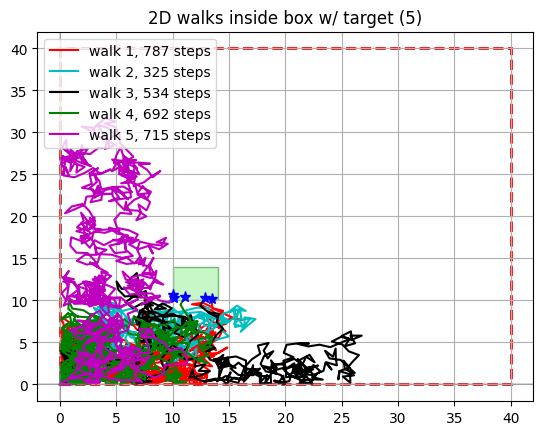

In [7]:
#
#  Executes target seeking random walk inside a
#  confining boundary(rectangle). Conducts and
#   plots up to 5 random walks
#
#  Following parameters can be changed:
#    1- Size and location of boundary
#    2- Size and location of target
#    3 -Starting location for random walk
#

import sys
import random as random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle  # Used to draw rectangle

def rand_angle():
    return random.uniform(0, 2 * np.pi)

def setup_box(bottom_left, width, height):
    x_min, y_min = bottom_left
    return (x_min, y_min, x_min + width, y_min + height)

def check_inside_box(x, y, box):
    x_min, y_min, x_max, y_max = box
    return x_min <= x <= x_max and y_min <= y <= y_max

def draw_boundary(start_loc, boundary):
    x_min, y_min, x_max, y_max = boundary
    rect = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor='r', facecolor='none', linestyle='--')
    plt.gca().add_patch(rect)
    plt.axvline(x=start_loc[0], color='gray', alpha=0.3)
    plt.axhline(y=start_loc[1], color='gray', alpha=0.3)

def draw_target(target):
    x_min, y_min, x_max, y_max = target
    rect = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=1, edgecolor='g', facecolor='lightgreen', alpha=0.5)
    plt.gca().add_patch(rect)


def random_walk_target(max_steps, start_loc, boundary, target):
    """  Performs a random walk inside a boundary with target """
    #  Start point for walk
    xpos, ypos = start_loc

    ###########################################
    #
    # Need to initialize xwalk and ywalk here!
    # You can either use numpy arrays or lists
    # But your algorithm will be different in
    # each case
    #
    ###########################################

    xwalk = [xpos]
    ywalk = [ypos]

    steps_taken = 0
    was_target_hit = False

    #  Conduct walk until target reached or max steps exceeded
    while steps_taken < max_steps :

        # Create trial move
        angle = rand_angle()
        xdelta = np.cos(angle)
        ydelta = np.sin(angle)

        xtrial = xpos + xdelta
        ytrial = ypos + ydelta

        #  Check if target reached. if so, end walk
#################################################################
#
#    YOUR CODE GOES HERE:
#       Use check_inside_box to check if trial move is in target box
#       If so;
#          1. Update x,y positions
#          2. Update walk sequences
#          3. Add one to steps_taken
#          4. Update was_target_hit to True
#          5. Break out of while loop, you're done
#
################################################################

        if check_inside_box(xtrial, ytrial, target):
            xpos = xtrial
            ypos = ytrial
            xwalk.append(xpos)
            ywalk.append(ypos)
            steps_taken += 1
            was_target_hit = True
            break


        # Check if still inside boundary. If so, accept move and continue
        if check_inside_box(xtrial, ytrial,boundary):
            ################################
            #
            # More code for you to write! :D
            #
            ################################
            xpos = xtrial
            ypos = ytrial
            xwalk.append(xpos)
            ywalk.append(ypos)
            steps_taken += 1

    return xwalk, ywalk, steps_taken, was_target_hit

#
#   Enter number of walks to plot and check entered value
#

num_walks = int(input('Enter number of walks to do (1-5) :  '))
max_steps = 1000 #Can change this to whatever you want (not too high though; runtimes can get quite long)


#
#  Set up confining box, target, starting point for walks, and random step function
#

boundary    = setup_box((0.0, 0.0), 40, 40) #Can change the size/position of the box
target      = setup_box((10.0, 10.0), 4, 4) #Can change the size/position of the target
start_loc   = (0.0, 0.0)

#  Allows each walk to use a different color/line type on plot
line_type = ['r-','c-','k-','g-','m-']

#
#  Perform loop for each walk and plot with different color(line_type):
#


for i in range(num_walks):
    xwalk1, ywalk1, steps_taken, target_reached = random_walk_target(max_steps, start_loc, boundary, target)
    plt.plot(xwalk1, ywalk1, line_type[i], label= f'walk {i+1}, {steps_taken} steps')
    plt.plot(xwalk1[-1], ywalk1[-1], 'b*', ms=8)  # Large * to mark end of walk

#
#  Draw boundary and target on graph and set size of graph (xlim,ylim)
#  Create bold lines through walk starting point
#

draw_boundary(start_loc, boundary)
draw_target(target)

#  Set plot title, legend, and grid
plt.title(f'2D walks inside box w/ target ({num_walks})' )
plt.legend(loc="upper left")
plt.grid(True)
#plt.savefig("rw2d_target1.png")
plt.show()

## Challenge Exercise

If you complete this program, try this for a challenge exercise:
    
>  Instead of a box, define the boundary and/or target using a circle or even  better, an ellipse to confine the random walker. Create a new program based on program above that uses a confining or target circle or ellipse to control and plot movement.

>  You will need to look up on the internet how to define and draw a circle or ellipse in the plane and how to determine if a point is inside or outside.

# 2D Random Walk with Target Statistics

Just as the case with 1D random walks, we are **not** just interested in the results of one or even a few random walks with a target. We are more interested in what happens when we execute the random walk over and over again. Can we see trends or averages that characterize the way a molecule moves at random inside a cell?

In fact, this program (with statistics) will be the basis of many of your final projects!!

With a full program in hand we can now answer questions like;

<span style="color:green">


> How does the shape and size of the cell boundary affect a walker's (or molecule's) time to find a target?

> How does the shape/size of the target affect the walker's time to find a target?

> How does initial distance from the target affect the walker's time to find it?

> Suppose we introduce multiple targets inside the boundary (same as in a typical cell which has multiple ribosomes for rRNA to find). How much does this speed up the process of finding at least one target?
    
> Lots of other questions/experiments you may dream up for your project    

</span>     
    

To capture this important information, we must run the random walk hundreds or thousands of times and gather **statistics** on the outcomes.

### Experiment

It seems logical that the walker will take longer to reach the target, if he/she starts further away from the target. Is its true? Also, is there a possible mathematical relationship between walker's starting distance from target and number of steps needed to reach the target?

**Questions for you to answer:**

> 1. What can you conclude about the affect of starting distance from target for the random walker? Was our original assumption correct?

> 2. Plot the distance from target against average number of steps (manually or with computer). Is there an apparent functional relationship? Linear, quadratic, something else?

> 3. Does the standard deviation of steps (a measure of variability of time to target) vary with the distance traveled to the target? How is standard deviation related to distance (if at all)?